# Notebook 1: Data Collection from World Bank API

## Overview

This notebook collects panel data for 19 MENA countries (1990–2023) from the World Bank Open Data API. All source indicators are publicly available and fetched programmatically to ensure reproducibility.

---


In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import wbgapi as wb
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("✓ Libraries loaded successfully!")


✓ Libraries loaded successfully!


## Data Source: World Bank Open Data API

The World Bank API provides programmatic access to 16,000+ international development indicators covering 217 countries from 1960 to the present. No authentication is required. Fetching data via API rather than manual download ensures a transparent and reproducible data pipeline.


In [2]:
# Define MENA countries using World Bank country codes
# These are ISO 3-letter country codes
mena_countries = {
    'DZA': 'Algeria',
    'BHR': 'Bahrain',
    'DJI': 'Djibouti',
    'EGY': 'Egypt, Arab Rep.',
    'IRN': 'Iran, Islamic Rep.',
    'IRQ': 'Iraq',
    'JOR': 'Jordan',
    'KWT': 'Kuwait',
    'LBN': 'Lebanon',
    'LBY': 'Libya',
    'MAR': 'Morocco',
    'OMN': 'Oman',
    'QAT': 'Qatar',
    'SAU': 'Saudi Arabia',
    'SYR': 'Syrian Arab Republic',
    'TUN': 'Tunisia',
    'ARE': 'United Arab Emirates',
    'PSE': 'West Bank and Gaza',
    'YEM': 'Yemen, Rep.'
}

print(f"We're analyzing {len(mena_countries)} MENA countries")
print("\nCountries included:")
for code, name in mena_countries.items():
    print(f"  {code}: {name}")


We're analyzing 19 MENA countries

Countries included:
  DZA: Algeria
  BHR: Bahrain
  DJI: Djibouti
  EGY: Egypt, Arab Rep.
  IRN: Iran, Islamic Rep.
  IRQ: Iraq
  JOR: Jordan
  KWT: Kuwait
  LBN: Lebanon
  LBY: Libya
  MAR: Morocco
  OMN: Oman
  QAT: Qatar
  SAU: Saudi Arabia
  SYR: Syrian Arab Republic
  TUN: Tunisia
  ARE: United Arab Emirates
  PSE: West Bank and Gaza
  YEM: Yemen, Rep.


## Indicator Definitions

**World Bank Indicator Codes** identify each series uniquely (e.g., SE.TER.ENRR). Full indicator documentation is available at [data.worldbank.org/indicator](https://data.worldbank.org/indicator).

**Key variables:**
1. **Treatment**: Gross tertiary education enrollment rate
2. **Outcome**: Youth unemployment rate (ages 15–24)
3. **Controls**: GDP per capita, urbanization rate, government education expenditure


In [3]:
# World Bank indicator codes mapped to variable names
indicators = {
    'SE.TER.ENRR': 'tertiary_enrollment',        # gross tertiary enrollment (%)
    'SL.UEM.1524.ZS': 'youth_unemployment',      # youth unemployment rate, ages 15-24
    'NY.GDP.PCAP.KD': 'gdp_per_capita',          # GDP per capita (constant 2015 USD)
    'SP.POP.GROW': 'population_growth',          # annual population growth (%)
    'SE.XPD.TOTL.GD.ZS': 'education_spending',   # govt education expenditure (% GDP)
    'SP.URB.TOTL.IN.ZS': 'urban_population',     # urban population (%)
    'SP.POP.1564.TO.ZS': 'working_age_pop',      # working-age population share (15-64)
    'SL.TLF.CACT.ZS': 'labor_force_participation' # labor force participation rate
}

print("Indicators to collect:")
for code, name in indicators.items():
    print(f"  {code} → {name}")


Indicators to collect:
  SE.TER.ENRR → tertiary_enrollment
  SL.UEM.1524.ZS → youth_unemployment
  NY.GDP.PCAP.KD → gdp_per_capita
  SP.POP.GROW → population_growth
  SE.XPD.TOTL.GD.ZS → education_spending
  SP.URB.TOTL.IN.ZS → urban_population
  SP.POP.1564.TO.ZS → working_age_pop
  SL.TLF.CACT.ZS → labor_force_participation


## Data Collection Function

A single reusable function queries the API, handles missing values, and returns a clean DataFrame for each indicator.


In [4]:
def fetch_wb_data(indicator_code, country_codes, start_year=1990, end_year=2023):
    """
    Fetch data from World Bank API for specified indicator and countries.
    
    Parameters:
    -----------
    indicator_code : str
        World Bank indicator code (e.g., 'SE.TER.ENRR')
    country_codes : list
        List of ISO 3-letter country codes
    start_year : int
        Starting year for data collection
    end_year : int
        Ending year for data collection
    
    Returns:
    --------
    pd.DataFrame : Panel data with countries and years
    """
    try:
        # Fetch data from World Bank
        data = wb.data.DataFrame(
            indicator_code,
            country_codes,
            time=range(start_year, end_year + 1),
            skipBlanks=False,
            columns='series'
        )
        
        # Reset index to get country and year as columns
        data = data.reset_index()
        data = data.rename(columns={'economy': 'country_code', 'time': 'year'})
        
        # Convert year to integer (handles 'YR2010' format from API)
        if data['year'].dtype == 'object':
            # Remove 'YR' prefix if present and convert to int
            data['year'] = data['year'].astype(str).str.replace('YR', '', regex=False).astype(int)
        else:
            data['year'] = data['year'].astype(int)
        
        # Rename value column to indicator name
        data = data.rename(columns={data.columns[2]: indicator_code})
        
        return data
    
    except Exception as e:
        print(f"⚠️  Error fetching {indicator_code}: {str(e)}")
        return None

print("✓ Data collection function defined")


✓ Data collection function defined


## Download All Indicators

The following cell fetches all indicators defined above. Runtime is approximately 1–2 minutes depending on connection speed.


In [5]:
# Fetch all indicators
print("Downloading data from World Bank API...\n")

dataframes = {}
country_codes = list(mena_countries.keys())

for idx, (indicator_code, indicator_name) in enumerate(indicators.items(), 1):
    print(f"[{idx}/{len(indicators)}] Fetching {indicator_name}...")
    df = fetch_wb_data(indicator_code, country_codes)
    
    if df is not None:
        dataframes[indicator_name] = df
        print(f"    ✓ Retrieved {len(df)} observations")
    else:
        print(f"    ✗ Failed to retrieve data")
    
print("\n✓ Data download complete!")



[1/8] Fetching tertiary_enrollment...
    ✓ Retrieved 646 observations
[2/8] Fetching youth_unemployment...
    ✓ Retrieved 646 observations
[3/8] Fetching gdp_per_capita...
    ✓ Retrieved 646 observations
[4/8] Fetching population_growth...
    ✓ Retrieved 646 observations
[5/8] Fetching education_spending...
    ✓ Retrieved 646 observations
[6/8] Fetching urban_population...
    ✓ Retrieved 646 observations
[7/8] Fetching working_age_pop...
    ✓ Retrieved 646 observations
[8/8] Fetching labor_force_participation...
    ✓ Retrieved 646 observations

✓ Data download complete!


## Merge Indicators into Panel Dataset

Each indicator is stored as a separate DataFrame. Merging on (country_code, year) produces a balanced panel where each row represents one country-year observation.


In [6]:
panel_data = dataframes['tertiary_enrollment'][['country_code', 'year']].copy()

for indicator_name, df in dataframes.items():
    indicator_col = [col for col in df.columns if col not in ['country_code', 'year']][0]
    df_to_merge = df[['country_code', 'year', indicator_col]].copy()
    df_to_merge = df_to_merge.rename(columns={indicator_col: indicator_name})
    
    panel_data = panel_data.merge(
        df_to_merge,
        on=['country_code', 'year'],
        how='left'
    )

# Add country names
panel_data['country'] = panel_data['country_code'].map(mena_countries)

# Reorder columns for readability
cols = ['country_code', 'country', 'year'] + [col for col in panel_data.columns if col not in ['country_code', 'country', 'year']]
panel_data = panel_data[cols]

print(f"✓ Panel dataset created!")
print(f"  Shape: {panel_data.shape[0]} observations × {panel_data.shape[1]} variables")
print(f"  Years: {panel_data['year'].min()} - {panel_data['year'].max()}")
print(f"  Countries: {panel_data['country_code'].nunique()}")


✓ Panel dataset created!
  Shape: 646 observations × 11 variables
  Years: 1990 - 2023
  Countries: 19


## Data Preview


In [7]:
# Display first few rows
print("First 10 rows of our panel data:\n")
display(panel_data.head(10))

# Data info
print("\n" + "="*50)
print("Data Structure:")
panel_data.info()


First 10 rows of our panel data:



,country_code,country,year,tertiary_enrollment,youth_unemployment,gdp_per_capita,population_growth,education_spending,urban_population,working_age_pop,labor_force_participation
0,ARE,United Arab Emirates,1990,NaN,NaN,66979.155915,5.878423,NaN,79.051,69.391851,74.385
1,ARE,United Arab Emirates,1991,NaN,3.912,63905.626470,5.553810,NaN,78.906,70.143956,74.654
2,ARE,United Arab Emirates,1992,NaN,4.048,62667.135448,5.247244,NaN,78.760,70.888530,74.952
3,ARE,United Arab Emirates,1993,NaN,4.283,60391.465584,4.952240,NaN,78.614,71.608958,75.464
4,ARE,United Arab Emirates,1994,NaN,4.298,61614.341591,4.664074,NaN,78.467,72.321136,75.812
5,ARE,United Arab Emirates,1995,NaN,4.345,62860.277325,4.471766,NaN,78.319,73.061995,76.180
6,ARE,United Arab Emirates,1996,NaN,4.482,62334.406659,6.476614,NaN,78.493,73.809538,76.050
7,ARE,United Arab Emirates,1997,NaN,4.574,62177.428382,8.124394,NaN,78.938,74.679098,75.370
8,ARE,United Arab Emirates,1998,NaN,4.773,57785.031141,7.617797,NaN,79.378,75.739564,74.887
9,ARE,United Arab Emirates,1999,NaN,4.967,55354.943961,7.157276,NaN,79.810,76.833668,74.610



Data Structure:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 646 entries, 0 to 645
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   country_code               646 non-null    object 
 1   country                    646 non-null    object 
 2   year                       646 non-null    int64  
 3   tertiary_enrollment        411 non-null    float64
 4   youth_unemployment         626 non-null    float64
 5   gdp_per_capita             614 non-null    float64
 6   population_growth          645 non-null    float64
 7   education_spending         276 non-null    float64
 8   urban_population           646 non-null    float64
 9   working_age_pop            646 non-null    float64
 10  labor_force_participation  645 non-null    float64
dtypes: float64(8), int64(1), object(2)
memory usage: 55.6+ KB


## Data Availability

Missing observations are common in international panel datasets, particularly for earlier years and smaller economies. The extent of missingness here determines the imputation strategy used in Notebook 2.


In [8]:
# Calculate missing data percentage
missing_stats = pd.DataFrame({
    'Variable': panel_data.columns[3:],  # Skip country_code, country, year
    'Missing Count': panel_data.iloc[:, 3:].isnull().sum().values,
    'Missing %': (panel_data.iloc[:, 3:].isnull().sum() / len(panel_data) * 100).round(2).values,
    'Available Count': panel_data.iloc[:, 3:].notna().sum().values
})

print("Data Availability Summary:\n")
display(missing_stats.sort_values('Missing %', ascending=False))



Data Availability Summary:



,Variable,Missing Count,Missing %,Available Count
4,education_spending,370,57.28,276
0,tertiary_enrollment,235,36.38,411
2,gdp_per_capita,32,4.95,614
1,youth_unemployment,20,3.10,626
3,population_growth,1,0.15,645
7,labor_force_participation,1,0.15,645
5,urban_population,0,0.00,646
6,working_age_pop,0,0.00,646



📌 Note: Missing data is common in international datasets.
   We'll handle this properly in the analysis phase.


## Save Raw Data

Raw data is saved before any transformation to preserve reproducibility and allow re-running the analysis from this checkpoint.


In [9]:
# Create data directories if they don't exist
Path('../data/raw').mkdir(parents=True, exist_ok=True)
Path('../data/processed').mkdir(parents=True, exist_ok=True)

# Save raw data
raw_file = '../data/raw/mena_panel_raw.csv'
panel_data.to_csv(raw_file, index=False)

print(f"✓ Raw data saved to: {raw_file}")
print(f"  File size: {Path(raw_file).stat().st_size / 1024:.2f} KB")


✓ Raw data saved to: ../data/raw/mena_panel_raw.csv
  File size: 69.69 KB


## Trends Overview

The plots below provide an initial look at the main variables across the panel period.


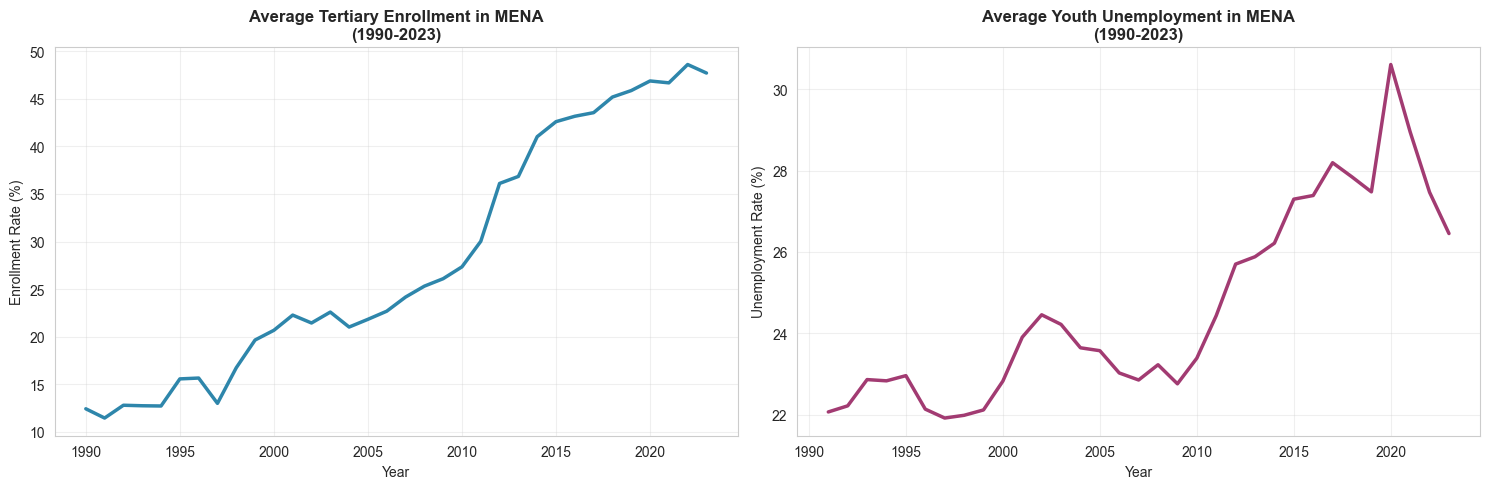

✓ Initial trend visualization saved


In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

# Create results/figures directory
Path('../results/figures').mkdir(parents=True, exist_ok=True)

# Plot tertiary enrollment trends
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Average tertiary enrollment over time
avg_enrollment = panel_data.groupby('year')['tertiary_enrollment'].mean()
axes[0].plot(avg_enrollment.index, avg_enrollment.values, linewidth=2.5, color='#2E86AB')
axes[0].set_title('Average Tertiary Enrollment in MENA\n(1990-2023)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Enrollment Rate (%)')
axes[0].grid(alpha=0.3)

# Average youth unemployment over time
avg_unemployment = panel_data.groupby('year')['youth_unemployment'].mean()
axes[1].plot(avg_unemployment.index, avg_unemployment.values, linewidth=2.5, color='#A23B72')
axes[1].set_title('Average Youth Unemployment in MENA\n(1990-2023)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Unemployment Rate (%)')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../results/figures/01_trends_overview.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Initial trend visualization saved")


## Summary

Data collection is complete. The panel covers 19 MENA countries over 30+ years with tertiary enrollment, youth unemployment, and economic control variables sourced from the World Bank API.

Notebook 2 proceeds with exploratory data analysis and cleaning.
